## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  5.61it/s]   

Successfully downloaded: airline-safety.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  5.58it/s]

Successfully downloaded: bad-drivers.csv


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [3]:
# TotalSleepTime → term_gpa (controlling for cum_gpa + demographics)


import pandas as pd
import numpy as np
import os
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt


#print(os.getcwd())
#!ls data/00-raw


# Load raw dataset



df_raw = pd.read_csv("data/00-raw/cmu-sleep.csv")

print("Initial shape:", df_raw.shape)


# Check missing values for key variables

key_columns = [
    'term_gpa',
    'cum_gpa',
    'TotalSleepTime',
    'term_units',
    'Zterm_units_ZofZ',
    'demo_race',
    'demo_gender',
    'demo_firstgen'
]

print("\nMissing values per column:")
print(df_raw[key_columns].isna().sum())

# Drop rows missing key variables

df_clean = df_raw.dropna(subset=[
    'term_gpa',
    'cum_gpa',
    'TotalSleepTime'
]).copy()


numeric_cols = [
    'term_gpa',
    'cum_gpa',
    'TotalSleepTime',
    'term_units',
    'Zterm_units_ZofZ'
]

for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


# Remove impossible GPA values

df_clean = df_clean[
    (df_clean['term_gpa'] >= 0) & (df_clean['term_gpa'] <= 4)
]

df_clean = df_clean[
    (df_clean['cum_gpa'] >= 0) & (df_clean['cum_gpa'] <= 4)
]

# ------------------------------------------
# Remove unrealistic sleep values. Unsure if we should keep/leave yet. Miniscule amounts of sleep aren't uncommon in college.
# ------------------------------------------
# df_clean = df_clean[
#     (df_clean['TotalSleepTime'] >= 120) & 
#     (df_clean['TotalSleepTime'] <= 900)
# ]


# Remove duplicates

df_clean = df_clean.drop_duplicates()


# Final Dataset Summary

print("\nFinal shape after cleaning:", df_clean.shape)
print("\nSummary statistics:")
print(df_clean.describe())

# ------------------------------------------
# Save cleaned dataset to 01-interim
# ------------------------------------------
df_clean.to_csv("data/01-interim/cmu_sleep_interim.csv", index=False)

print("\nInterim dataset saved to data/01-interim/cmu_sleep_interim.csv")
print("\nData cleaning complete.")


print("___________________________________________________")
shape_tbl = pd.DataFrame({
    "Dataset": ["Raw", "Cleaned"],
    "Rows": [df_raw.shape[0], df_clean.shape[0]],
    "Cols": [df_raw.shape[1], df_clean.shape[1]],
})

display(
    shape_tbl.style
    .hide(axis="index")
    .set_caption("Dataset shapes (before vs after cleaning)")
)

#  Missingness (count + %) ----------
miss = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_pct": (df_clean.isna().mean() * 100)
}).sort_values("missing_count", ascending=False)

miss_show = miss[miss["missing_count"] > 0].copy()
if miss_show.empty:
    miss_show = pd.DataFrame({"missing_count": [0], "missing_pct": [0.0]}, index=["(no missing values)"])

display(
    miss_show.style
    .format({"missing_count": "{:,.0f}", "missing_pct": "{:.2f}%"})
    .bar(subset=["missing_pct"])
    .set_caption("Missing values by column")
)


# Show numeric columns only, rounded
desc = df_clean.describe(include=[np.number]).T
desc = desc.rename(columns={
    "count": "n", "mean": "mean", "std": "std", "min": "min",
    "25%": "p25", "50%": "median", "75%": "p75", "max": "max"
})

display(
    desc.style
    .format("{:,.3f}")
    .set_caption("Summary statistics (numeric columns)")
)

units_cols = [c for c in ["term_units", "Zterm_units_ZofZ"] if c in df_clean.columns]
if units_cols:
    units_cov = pd.DataFrame({
        "column": units_cols,
        "non_null_count": [df_clean[c].notna().sum() for c in units_cols],
        "non_null_pct": [df_clean[c].notna().mean() * 100 for c in units_cols],
    })
    display(
        units_cov.style
        .hide(axis="index")
        .format({"non_null_count": "{:,.0f}", "non_null_pct": "{:.2f}%"})
        .set_caption("Course load columns coverage (units)")
    )
else:
    print("term_units / Zterm_units_ZofZ not found in df columns.")

os.makedirs("data/02-processed", exist_ok=True)
df_clean.to_csv("data/02-processed/cmu_sleep_processed.csv", index=False)
print("Processed dataset saved to data/02-processed/cmu_sleep_processed.csv")

Initial shape: (634, 15)

Missing values per column:
term_gpa            0
cum_gpa             0
TotalSleepTime      0
term_units          0
Zterm_units_ZofZ    0
demo_race           0
demo_gender         0
demo_firstgen       0
dtype: int64

Final shape after cleaning: (634, 15)

Summary statistics:
         subject_id       study  bedtime_mssd  TotalSleepTime  midpoint_sleep  \
count    634.000000  634.000000    634.000000      634.000000      634.000000   
mean   13005.892744    3.181388      0.451688      397.323874      398.679186   
std    26496.593477    1.317125      1.393632       50.856725       72.710945   
min        1.000000    1.000000      0.004505      194.782609      247.071429   
25%      178.000000    2.000000      0.074694      366.930077      345.182692   
50%      358.500000    3.000000      0.135007      400.395833      388.245726   
75%      592.750000    4.000000      0.291698      430.114583      437.655263   
max    99978.000000    5.000000     20.849225     

Dataset,Rows,Cols
Raw,634,15
Cleaned,634,15


,missing_count,missing_pct
term_units,147,23.19%
Zterm_units_ZofZ,147,23.19%


,n,mean,std,min,p25,median,p75,max
subject_id,634.000,"13,005.893","26,496.593",1.000,178.000,358.500,592.750,"99,978.000"
study,634.000,3.181,1.317,1.000,2.000,3.000,4.000,5.000
bedtime_mssd,634.000,0.452,1.394,0.005,0.075,0.135,0.292,20.849
TotalSleepTime,634.000,397.324,50.857,194.783,366.930,400.396,430.115,587.667
midpoint_sleep,634.000,398.679,72.711,247.071,345.183,388.246,437.655,724.667
frac_nights_with_data,634.000,0.867,0.179,0.214,0.821,0.932,1.000,1.000
daytime_sleep,634.000,41.164,27.389,2.269,23.098,34.982,51.249,292.304
cum_gpa,634.000,3.466,0.438,1.210,3.232,3.558,3.790,4.000
term_gpa,634.000,3.450,0.500,0.350,3.233,3.556,3.810,4.000
term_units,487.000,29.392,17.643,5.000,15.000,17.000,48.000,73.000


column,non_null_count,non_null_pct
term_units,487,76.81%
Zterm_units_ZofZ,487,76.81%


Processed dataset saved to data/02-processed/cmu_sleep_processed.csv


### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [4]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Overview on Sleep TIme and Performance

To better understand the relationship between sleep behavior and academic performance, we conducted several exploratory analyses using the cleaned dataset. We first examined the distribution of total sleep time among students. The histogram shows that most students sleep between approximately 350 and 450 minutes per night (about 5.8–7.5 hours), with the distribution centered around roughly 400 minutes (6.7 hours). This indicates that while sleep duration varies across students, the majority of observations cluster within a relatively narrow range.

Next, we explored how sleep duration varies across different academic performance groups. Students were grouped into GPA categories (Low, Medium, High, and Very High), and sleep duration was compared across these groups using a boxplot. The results suggest a modest trend in which students with higher GPAs tend to have slightly higher median sleep durations. However, there is still considerable overlap between the groups, indicating that sleep duration alone does not strongly determine academic performance.

We also investigated the relationship between sleep schedule regularity and GPA using the bedtime variability metric (bedtime_mssd). The scatterplot suggests a slight negative relationship between sleep irregularity and academic performance, meaning that students with more irregular sleep schedules tend to have slightly lower GPAs on average. This pattern is further supported by the grouped boxplot, where students with more consistent sleep schedules generally show slightly higher median GPAs compared to those with irregular sleep patterns.

Overall, these exploratory analyses suggest that while both sleep duration and sleep consistency show some association with academic performance, the relationships appear relatively modest. Academic performance likely depends on multiple factors beyond sleep behavior, but the results indicate that maintaining adequate and consistent sleep may still contribute positively to student outcomes.



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

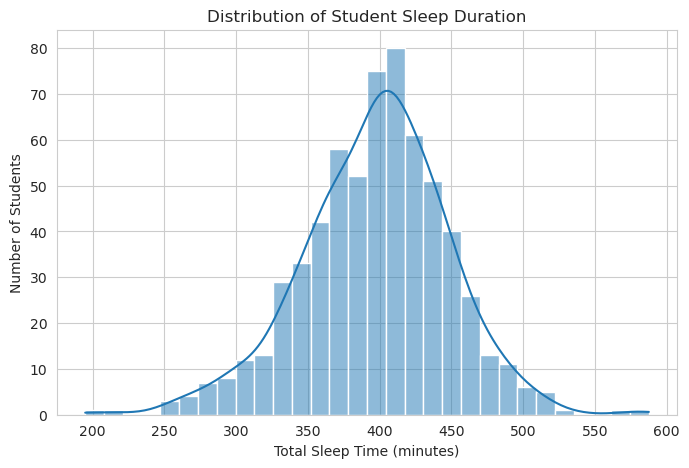

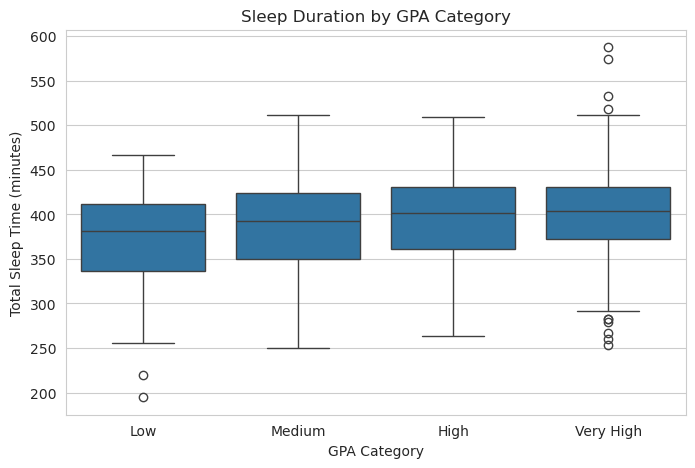

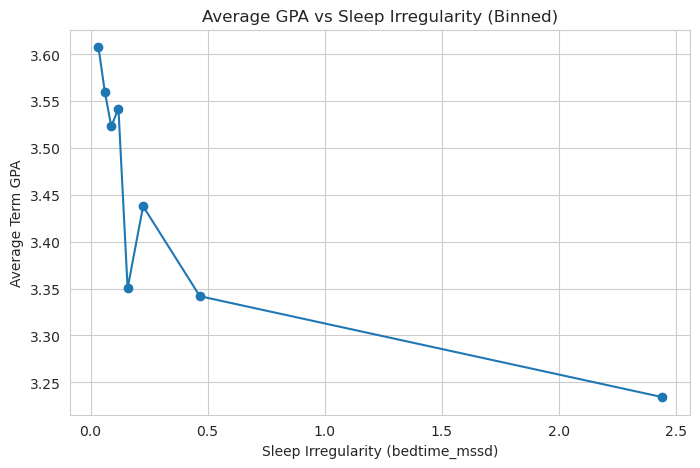

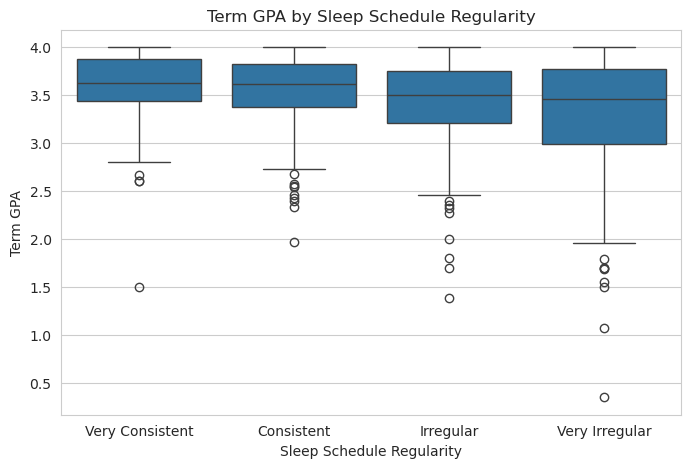

In [5]:
df = pd.read_csv("data/02-processed/cmu_sleep_processed.csv")
sns.set_style("whitegrid")

#-------- Sleep distribution---------------
plt.figure(figsize=(8,5))

sns.histplot(df_clean["TotalSleepTime"], bins=30, kde=True)

plt.title("Distribution of Student Sleep Duration")
plt.xlabel("Total Sleep Time (minutes)")
plt.ylabel("Number of Students")

plt.show()

#------------------------------
#-----------Compare GPA with sleep duration 
df_clean["gpa_category"] = pd.cut(
    df_clean["term_gpa"],
    bins=[0,2.5,3.0,3.5,4.0],
    labels=["Low","Medium","High","Very High"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="gpa_category",
    y="TotalSleepTime"
)

plt.title("Sleep Duration by GPA Category")
plt.xlabel("GPA Category")
plt.ylabel("Total Sleep Time (minutes)")

plt.show()

#---------------------------------------------

df_plot = df_clean.copy()


df_plot["irregularity_bin"] = pd.qcut(df_plot["bedtime_mssd"], 8)


binned = df_plot.groupby("irregularity_bin", observed = False)["term_gpa"].mean().reset_index()


binned["mid"] = df_plot.groupby("irregularity_bin", observed = False)["bedtime_mssd"].mean().values

plt.figure(figsize=(8,5))

plt.plot(binned["mid"], binned["term_gpa"], marker="o")

plt.title("Average GPA vs Sleep Irregularity (Binned)")
plt.xlabel("Sleep Irregularity (bedtime_mssd)")
plt.ylabel("Average Term GPA")

plt.grid(True)
plt.show()

#--------------------------------------------
df_clean["sleep_irregularity_group"] = pd.qcut(
    df_clean["bedtime_mssd"],
    4,
    labels=["Very Consistent","Consistent","Irregular","Very Irregular"]
)


plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="sleep_irregularity_group",
    y="term_gpa"
)

plt.title("Term GPA by Sleep Schedule Regularity")
plt.xlabel("Sleep Schedule Regularity")
plt.ylabel("Term GPA")

plt.show()

#### Sleep Duration and Academic Performance Across Demographic Groups
The regression analysis shows a weak positive relationship between total sleep time and term GPA, suggesting that students who sleep longer tend to have slightly higher academic performance on average. The correlation matrix supports this observation, showing a modest correlation between sleep duration and term GPA (r ≈ 0.20), while the strongest relationship appears between term GPA and cumulative GPA (r ≈ 0.64). When examining the relationship across demographic groups, the overall trend remains consistent, indicating that the association between sleep duration and GPA appears similar across gender, race, and first-generation status groups.

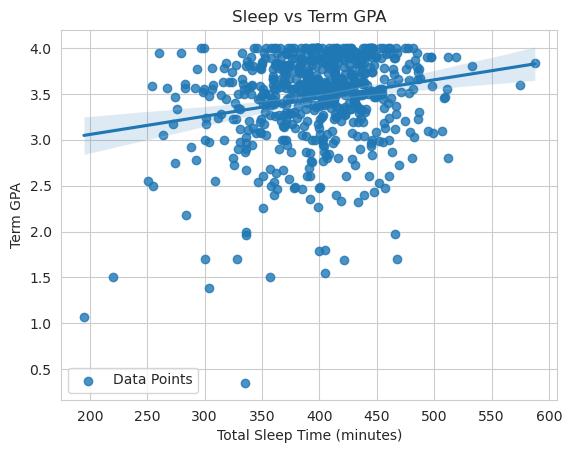

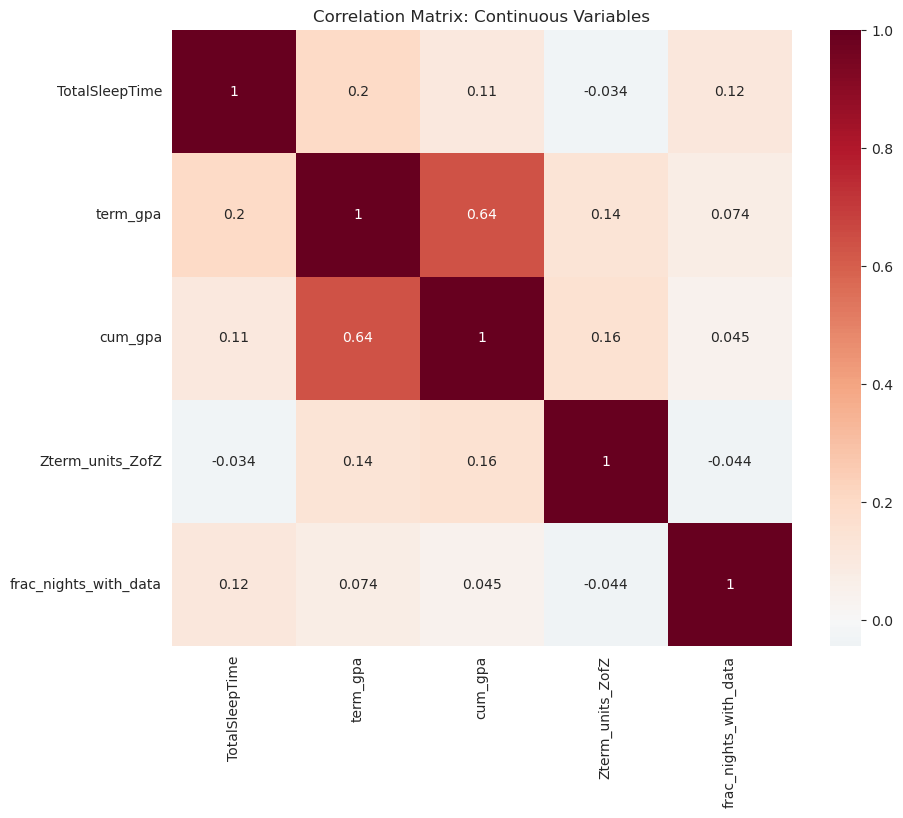

Correlation with Term GPA:
term_gpa                 1.000000
cum_gpa                  0.638035
TotalSleepTime           0.201677
Zterm_units_ZofZ         0.140686
frac_nights_with_data    0.074121
Name: term_gpa, dtype: float64


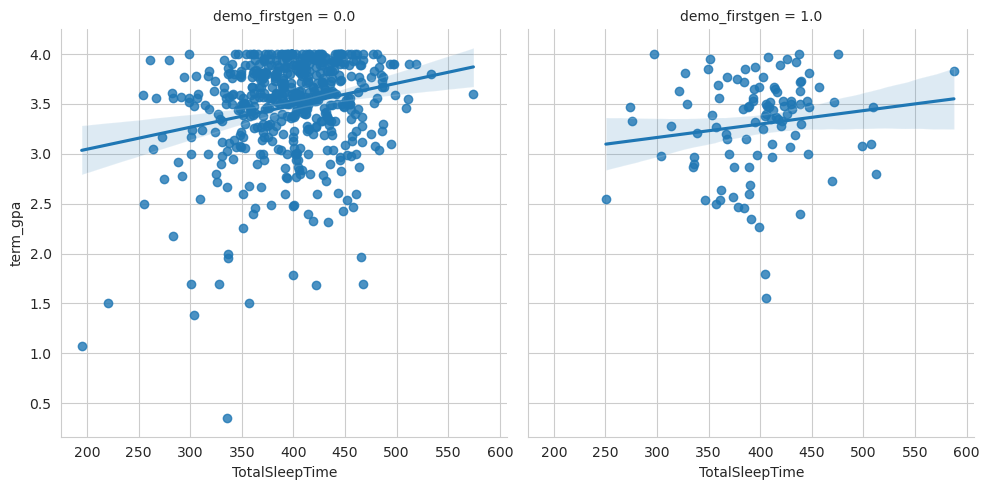

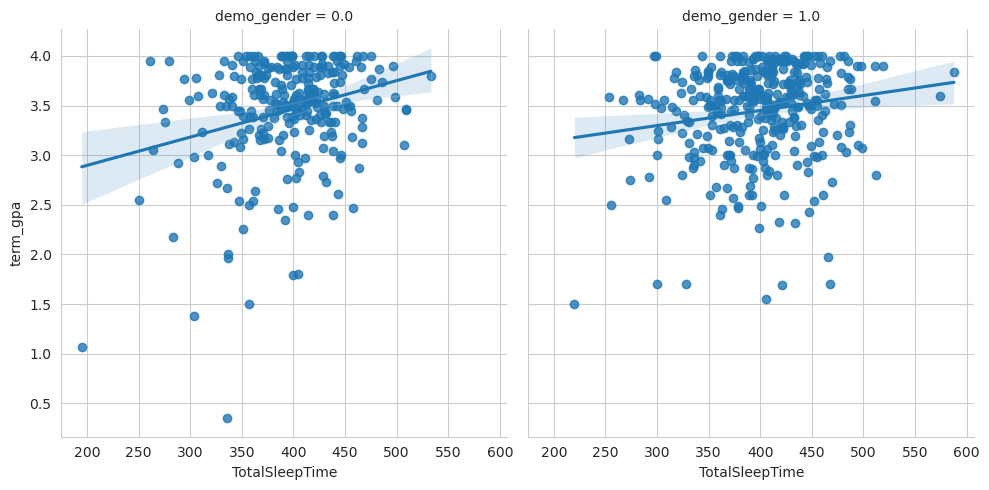

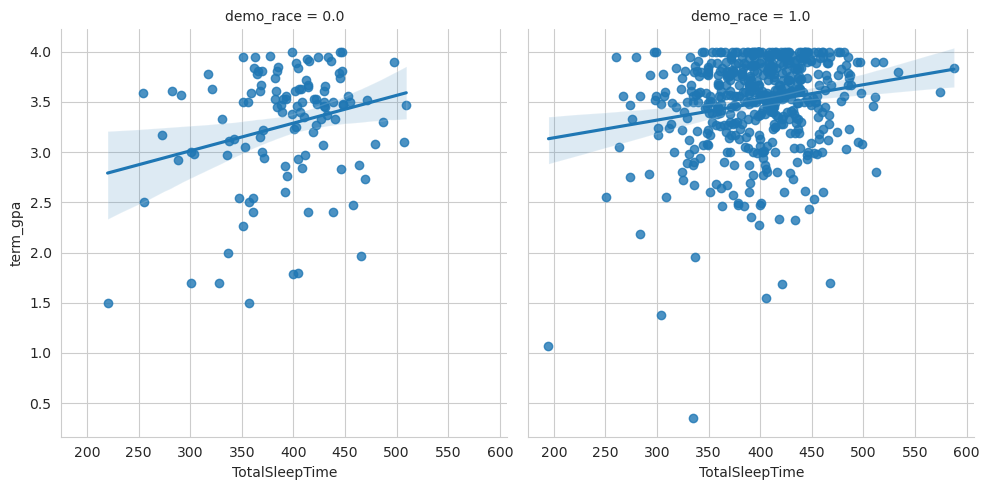

In [6]:
import matplotlib.pyplot as plt

vars_of_interest = [
    'TotalSleepTime', 'term_gpa', 'cum_gpa', 
    'Zterm_units_ZofZ', 'demo_gender', 'demo_race', 
    'demo_firstgen', 'frac_nights_with_data'
]


continuous_vars = [
    'TotalSleepTime', 
    'term_gpa', 
    'cum_gpa', 
    'Zterm_units_ZofZ', 
    'frac_nights_with_data'
]

# 1. Regression Plot
sns.regplot(data=df, x='TotalSleepTime', y='term_gpa', label='Data Points')
plt.title('Sleep vs Term GPA')
plt.xlabel('Total Sleep Time (minutes)')
plt.ylabel('Term GPA')
plt.legend()
plt.show()


# 2. Correlation Matrix (Filtered for continuous variables)
plt.figure(figsize=(10, 8))
# Only correlate the continuous columns
corr_matrix = df[continuous_vars].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix: Continuous Variables')
plt.show()

# --- 3. QUICK STATS SUMMARY ---
print("Correlation with Term GPA:")
print(corr_matrix['term_gpa'].sort_values(ascending=False))


# need to get clean demo_ data
df_clean = df.copy()
demo_cols = ['demo_firstgen', 'demo_gender', 'demo_race']
for col in demo_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')    
    df_clean = df_clean[df_clean[col].isin([0, 1])]


# Control for First-Gen status visually
sns.lmplot(data=df_clean, x='TotalSleepTime', y='term_gpa', col='demo_firstgen')
sns.lmplot(data=df_clean, x='TotalSleepTime', y='term_gpa', col='demo_gender')
sns.lmplot(data=df_clean, x='TotalSleepTime', y='term_gpa', col='demo_race')

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them